# Импорт библиотек

In [1]:
%pip install statsforecast datasetsforecast plotly catboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 945.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 1.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import random

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from datasetsforecast.m4 import M4

from statsmodels.graphics.tsaplots import plot_acf

from statsforecast import StatsForecast
from statsforecast.models import  Naive, SeasonalNaive, AutoETS, AutoTheta

import sys

import catboost

import importlib

In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)


seed_everything()

# Загрузка данных и EDA

В работе используется датасет M4.

Для ускорения экспериментов и удобства анализа было выбрано 100 случайных временных рядов.

In [4]:
data, *_ = M4.load(directory="data", group="Monthly")

91.7MiB [00:01, 57.6MiB/s]
7.94MiB [00:00, 47.7MiB/s]
4.34MiB [00:00, 80.3MiB/s]                 
100%|██████████| 3.56M/3.56M [00:00<00:00, 42.9MiB/s]


In [5]:
ids = np.random.choice(data['unique_id'].unique(), 100, replace=False)
data = data[data['unique_id'].isin(ids)]

In [6]:
data.groupby('unique_id').size().describe()

,0
count,100.000000
mean,224.880000
std,140.401537
min,79.000000
25%,96.750000
50%,193.000000
75%,324.000000
max,840.000000


In [7]:
fig = px.line(
    data,
    x="ds",
    y="y",
    color="unique_id"
)
fig.show()

Ряды имеют различную динамику и масштаб значений. Для некоторых рядов наблюдаются признаки сезонности.

In [ ]:
lengths = data.groupby('unique_id').size().reset_index(name='length')

fig = px.histogram(
    lengths,
    x="length",
    nbins=20,
    title="Распределение длин рядов"
)

fig.show()

Длины рядов варьируются, однако большинство рядов имеет сопоставимую продолжительность наблюдений.

In [ ]:
means = data.groupby('unique_id')['y'].mean().reset_index()

fig = px.histogram(
    means,
    x="y",
    nbins=50,
    title="Распределение средних значений рядов"
)

fig.show()

Распределение средних значений временных рядов подтверждает, что ряды имеют различный масштаб.

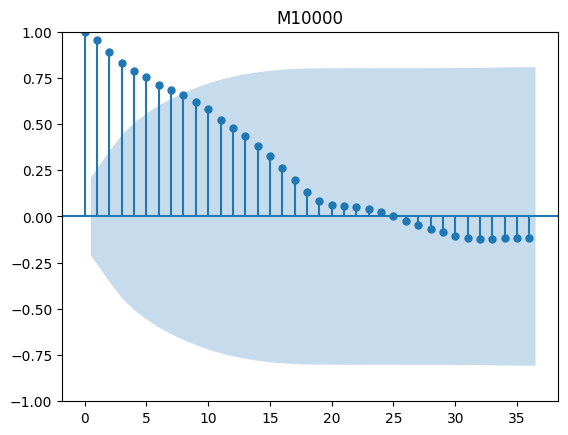

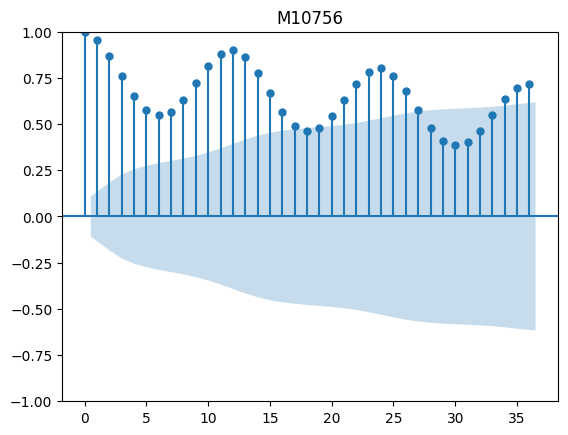

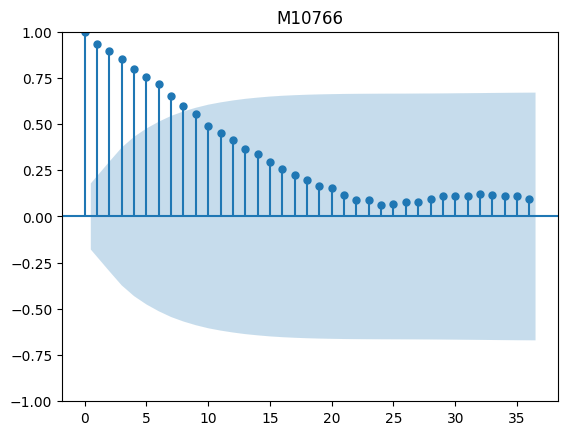

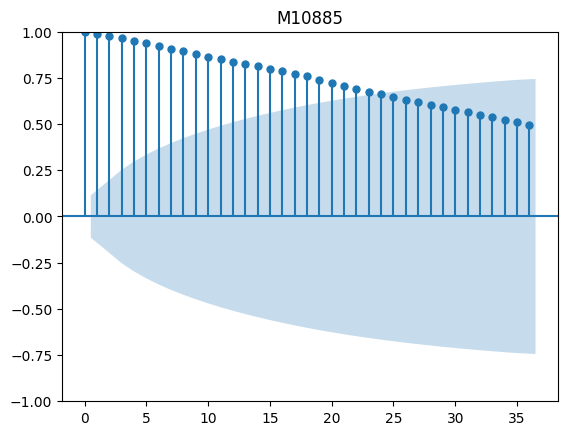

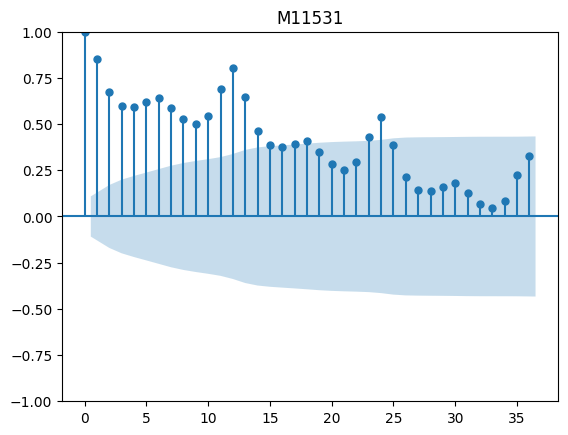

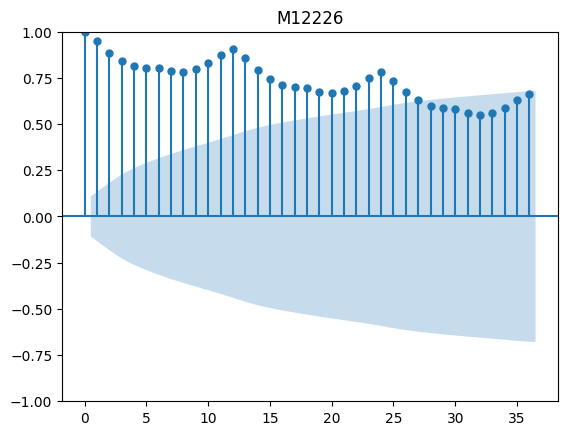

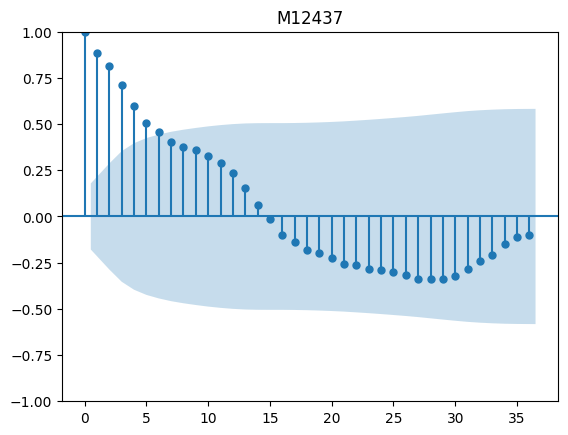

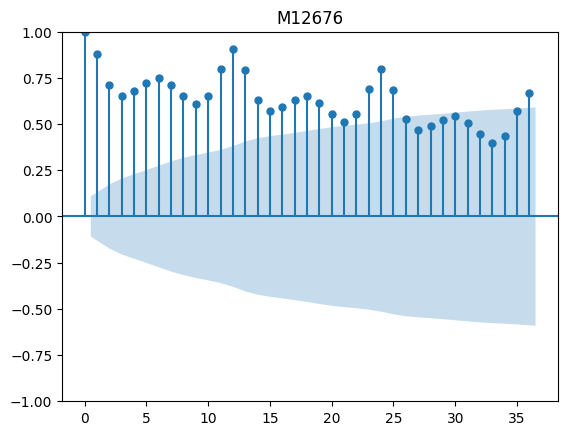

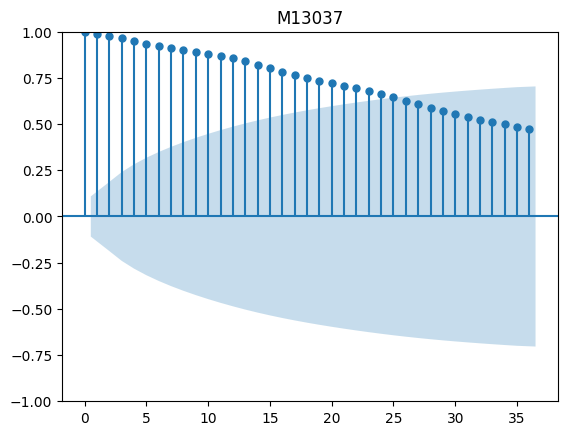

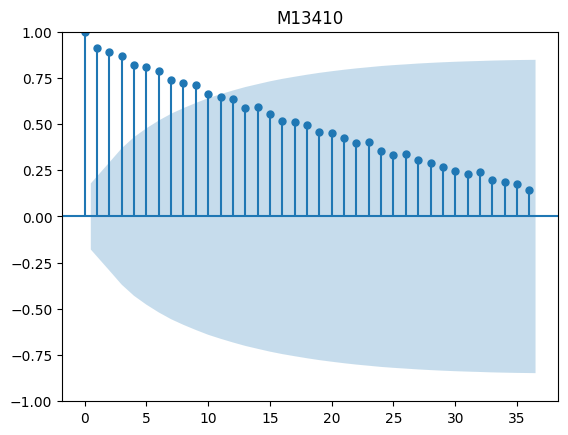

In [ ]:
sample_ids = data['unique_id'].unique()[:10]

for uid in sample_ids:
    ts = data[data.unique_id == uid]['y']
    plot_acf(ts, lags=36)
    plt.title(uid)
    plt.show()

По графикам автокорреляционной функции (ACF) для 10 случайно выбранных рядов видно, что наблюдения обладают значимой автокорреляцией. Для некоторых рядов наблюдаются выраженные пики на лагах 12 и 24 что указывает на наличие годовой сезонности.

# Построение бейзлайнов

Горизонт прогнозирования выбран равным 18. Это значение позволяет оценивать качество моделей на достаточно длинном промежутке времени и захватить период сезонности.

In [8]:
HORIZON = 18
train = data.groupby('unique_id').apply(lambda x: x.iloc[:-HORIZON]).reset_index(drop=True)
test = data.groupby('unique_id').apply(lambda x: x.iloc[-HORIZON:]).reset_index(drop=True)

/tmp/ipykernel_491/345730960.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_491/345730960.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



В качестве базовых моделей были использованы классические подходы к прогнозированию временных рядов.

In [ ]:
sf = StatsForecast(
    models=[
        AutoETS(season_length=12),
        AutoTheta(season_length=12),
        Naive(),
        SeasonalNaive(season_length=12),
    ],
    freq="ME",
    n_jobs=-1,
    verbose=True
)

preds = sf.forecast(df=train, h=HORIZON)

Forecast:   0%|          | 0/100 [Elapsed: 00:00]

In [ ]:
preds["ds"] = test["ds"].values

In [ ]:
def smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred) + eps) / 2
    return 100 * np.mean(numerator / denominator)


def get_smape_metrics(
    test_df: pd.DataFrame,
    forecast_df: pd.DataFrame,
    id_col: str = "unique_id",
    time_col: str = "ds",
    target_col: str = "y",
) -> pd.DataFrame:
    test_with_preds = test_df.merge(
        forecast_df,
        on=[id_col, time_col],
        how="left",
    )

    model_names = [
        col for col in forecast_df.columns if col not in [id_col, time_col]
    ]

    smape_results = {}

    for model_name in model_names:
        smape_results[model_name] = {}

        # общая метрика по всем точкам
        smape_results[model_name]["all_points"] = smape(
            test_with_preds[target_col].values,
            test_with_preds[model_name].values,
        )

        # по каждому ряду отдельно
        series_scores = []
        for series_id in test_df[id_col].unique():
            test_series = test_with_preds[test_with_preds[id_col] == series_id]
            score = smape(
                test_series[target_col].values,
                test_series[model_name].values,
            )
            smape_results[model_name][series_id] = score
            series_scores.append(score)

        # среднее по рядам
        smape_results[model_name]["mean_by_series"] = np.mean(series_scores)

    return pd.DataFrame(smape_results)

In [ ]:
def mase(y_true: np.ndarray, y_pred: np.ndarray, y_train: np.ndarray, m: int = 1, eps: float = 1e-8) -> float:
    if len(y_train) <= m:
        return np.nan

    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    if scale < eps:
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale


def get_mase_metrics(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    forecast_df: pd.DataFrame,
    id_col: str = "unique_id",
    time_col: str = "ds",
    target_col: str = "y",
    seasonality: int = 12,
) -> pd.DataFrame:
    test_with_preds = test_df.merge(
        forecast_df,
        on=[id_col, time_col],
        how="left",
    )

    model_names = [
        col for col in forecast_df.columns if col not in [id_col, time_col]
    ]

    mase_results = {}

    for model_name in model_names:
        mase_results[model_name] = {}
        series_scores = []

        for series_id in test_df[id_col].unique():
            train_series = train_df[train_df[id_col] == series_id][target_col].values
            test_series = test_with_preds[test_with_preds[id_col] == series_id]

            score = mase(
                y_true=test_series[target_col].values,
                y_pred=test_series[model_name].values,
                y_train=train_series,
                m=seasonality,
            )
            mase_results[model_name][series_id] = score
            series_scores.append(score)

        mase_results[model_name]["mean_by_series"] = np.nanmean(series_scores)

    return pd.DataFrame(mase_results)

В качестве метрик качества были выбраны sMAPE и MASE.
Метрика sMAPE не зависит от масштаба временных рядов, что важно в данной задаче, поскольку рассматриваемые ряды имеют различный масштаб значений.
Метрика MASE используется как относительная метрика и позволяет сравнивать качество модели с наивным прогнозом вида $\hat{y}_t = y_{t-1}$

In [ ]:
smape_table = get_smape_metrics(test, preds)
mase_table = get_mase_metrics(train, test, preds, seasonality=12)

In [ ]:
baseline_metrics = pd.DataFrame({
    "sMAPE": smape_table.loc["mean_by_series"],
    "MASE": mase_table.loc["mean_by_series"],
}).reset_index().rename(columns={"index": "model"})

baseline_metrics = baseline_metrics.sort_values(["sMAPE", "MASE"])
baseline_metrics

,model,sMAPE,MASE
1,AutoTheta,15.552270,0.992397
0,AutoETS,15.818659,0.968117
2,Naive,17.754215,1.151728
3,SeasonalNaive,19.148227,1.244893


Среди бейзлайнов наилучшее качество показала модель AutoTheta, за ней следует AutoETS. Простая модель Naive демонстрирует более высокую ошибку, что ожидаемо. Модель SeasonalNaive показала наихудший результат, что может свидетельствовать о том, что сезонная структура в выбранных рядах выражена не слишком сильно или нестабильна.

In [9]:
def plot_forecast(
    train_df,
    eval_df,
    series_id,
    models,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Forecast"
):
    train_series = train_df[train_df[id_col] == series_id].copy()
    test_series = eval_df[eval_df[id_col] == series_id].copy()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=train_series[time_col],
        y=train_series[target_col],
        mode="lines",
        name="Train"
    ))

    fig.add_trace(go.Scatter(
        x=test_series[time_col],
        y=test_series[target_col],
        mode="lines+markers",
        name="Test (real)"
    ))

    for model in models:
        fig.add_trace(go.Scatter(
            x=test_series[time_col],
            y=test_series[model],
            mode="lines+markers",
            name=model
        ))

    fig.update_layout(
        title=f"{title_prefix}: {series_id}",
        xaxis_title=time_col,
        yaxis_title=target_col,
        template="plotly_white",
        legend_title="Series",
        hovermode="x unified"
    )

    fig.show()

In [ ]:
plot_forecast(
    train_df=train,
    eval_df=test.merge(preds, on=["unique_id","ds"]),
    series_id="M10756",
    models=["AutoETS", "AutoTheta", "Naive", "SeasonalNaive"]
)

# Модель CatBoost Direct Mimo / Mimo

## model_horizon=6, history=24,  horizon=18

### Только обычные лаги

In [30]:
!git clone https://github.com/Katiukh/TS_HW3.git

Cloning into 'TS_HW3'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 13 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 10.85 KiB | 10.85 MiB/s, done.


In [ ]:
!rm -rf /content/TimeSeriesHWs

In [11]:
sys.path.append("/content/TimeSeriesHWs/TS_HW3")

В качестве глобальной модели выбрана схема Direct-MIMO на CatBoost. Общий горизонт прогнозирования составляет 18 шагов, для первой конфигурации прогноз строится тремя независимыми блоками по 6 шагов. Такой подход уменьшает сложность задачи по сравнению с предсказанием всех 18 значений одной моделью и при этом не накапливает ошибки так, как рекурсивная стратегия.

In [12]:
import importlib
import modules.index_slicing
import modules.models
import modules.holdout
import modules.metrics

importlib.reload(modules.index_slicing)
importlib.reload(modules.metrics)
importlib.reload(modules.models)
importlib.reload(modules.holdout)

<module 'modules.holdout' from '/content/TimeSeriesHWs/HW_2/modules/holdout.py'>

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result["sMAPE"])
print("MASE:", result["MASE"])

0:	learn: 7591.2587214	test: 8947.0828570	best: 8947.0828570 (0)	total: 464ms	remaining: 1m 32s
100:	learn: 1381.5067392	test: 2577.7922090	best: 2543.7381740 (58)	total: 51.8s	remaining: 50.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2543.738174
bestIteration = 58

Shrink model to first 59 iterations.
0:	learn: 7664.5227093	test: 8730.0737707	best: 8730.0737707 (0)	total: 436ms	remaining: 1m 26s
100:	learn: 1685.6744029	test: 2818.4896790	best: 2806.9795132 (76)	total: 51.2s	remaining: 50.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2806.979513
bestIteration = 76

Shrink model to first 77 iterations.
0:	learn: 7725.7591053	test: 8738.7558509	best: 8738.7558509 (0)	total: 447ms	remaining: 1m 28s
100:	learn: 1875.8703475	test: 3207.6386524	best: 3107.4719399 (54)	total: 46.1s	remaining: 45.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3107.47194
bestIteration = 54

Shrink model to first 55 iterations.
sMAPE: 15.2522

### Календарные признаки

In [ ]:
from modules.feature_configs import lags_calendar_config

result_calendar = run_holdout_experiment(
    data=train,
    feature_config=lags_calendar_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_calendar["sMAPE"])
print("MASE:", result_calendar["MASE"])

0:	learn: 7588.4656036	test: 8916.5974799	best: 8916.5974799 (0)	total: 1.73s	remaining: 5m 44s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2572.933604
bestIteration = 44

Shrink model to first 45 iterations.
0:	learn: 7652.7168861	test: 8789.1125042	best: 8789.1125042 (0)	total: 1.9s	remaining: 6m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2889.339942
bestIteration = 48

Shrink model to first 49 iterations.
0:	learn: 7735.1696975	test: 8695.9214386	best: 8695.9214386 (0)	total: 1.56s	remaining: 5m 10s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2958.442191
bestIteration = 35

Shrink model to first 36 iterations.
sMAPE: 15.110253694300482
MASE: 1.338828614313216


### Лаги + сезонные лаги

In [ ]:
from modules.feature_configs import lags_seasonal_config

result_seasonal = run_holdout_experiment(
    data=train,
    feature_config=lags_seasonal_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_seasonal["sMAPE"])
print("MASE:", result_seasonal["MASE"])

0:	learn: 7577.0414062	test: 8902.6065350	best: 8902.6065350 (0)	total: 427ms	remaining: 1m 24s
100:	learn: 1412.6525305	test: 2557.7868982	best: 2508.9825115 (53)	total: 48.4s	remaining: 47.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2508.982511
bestIteration = 53

Shrink model to first 54 iterations.
0:	learn: 7654.2496867	test: 8758.8364114	best: 8758.8364114 (0)	total: 414ms	remaining: 1m 22s
100:	learn: 1743.3278684	test: 2771.6358612	best: 2752.2529417 (55)	total: 46.1s	remaining: 45.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2752.252942
bestIteration = 55

Shrink model to first 56 iterations.
0:	learn: 7724.7824232	test: 8769.4085332	best: 8769.4085332 (0)	total: 632ms	remaining: 2m 5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3174.969189
bestIteration = 38

Shrink model to first 39 iterations.
sMAPE: 14.999170052693454
MASE: 1.355325234326952


### Фурье признаки

In [ ]:
from modules.feature_configs import lags_fourier_config

result_fourier = run_holdout_experiment(
    data=train,
    feature_config=lags_fourier_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_fourier["sMAPE"])
print("MASE:", result_fourier["MASE"])

0:	learn: 7574.2519162	test: 8893.7017168	best: 8893.7017168 (0)	total: 755ms	remaining: 2m 30s
100:	learn: 1394.8219628	test: 2565.9454141	best: 2554.5996829 (73)	total: 53.5s	remaining: 52.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2554.599683
bestIteration = 73

Shrink model to first 74 iterations.
0:	learn: 7647.1557140	test: 8772.6605631	best: 8772.6605631 (0)	total: 912ms	remaining: 3m 1s
100:	learn: 1690.6171998	test: 2840.0124674	best: 2821.0124290 (72)	total: 52.9s	remaining: 51.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2821.012429
bestIteration = 72

Shrink model to first 73 iterations.
0:	learn: 7740.1683467	test: 8767.9890047	best: 8767.9890047 (0)	total: 476ms	remaining: 1m 34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3140.452306
bestIteration = 37

Shrink model to first 38 iterations.
sMAPE: 15.276255093623586
MASE: 1.3456403996589226


### Лаги + сезонные лаги + календарные признаки

In [ ]:
from modules.feature_configs import lags_seasonal_calendar_config

result_combo1 = run_holdout_experiment(
    data=train,
    feature_config=lags_seasonal_calendar_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_combo1["sMAPE"])
print("MASE:", result_combo1["MASE"])

0:	learn: 7595.3156223	test: 8944.8301858	best: 8944.8301858 (0)	total: 1.81s	remaining: 6m
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2500.718182
bestIteration = 47

Shrink model to first 48 iterations.
0:	learn: 7674.1930210	test: 8776.2898034	best: 8776.2898034 (0)	total: 1.71s	remaining: 5m 39s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2892.988662
bestIteration = 41

Shrink model to first 42 iterations.
0:	learn: 7732.3825352	test: 8757.7817038	best: 8757.7817038 (0)	total: 1.55s	remaining: 5m 7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3148.629795
bestIteration = 27

Shrink model to first 28 iterations.
sMAPE: 15.569865298028963
MASE: 1.5187881790785918


### Лаги + Фурье признаки + календарные признаки

In [ ]:
from modules.feature_configs import lags_fourier_calendar_config

result_combo2 = run_holdout_experiment(
    data=train,
    feature_config=lags_fourier_calendar_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_combo2["sMAPE"])
print("MASE:", result_combo2["MASE"])

0:	learn: 7597.8366794	test: 8906.4367482	best: 8906.4367482 (0)	total: 1.72s	remaining: 5m 42s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2554.159337
bestIteration = 48

Shrink model to first 49 iterations.
0:	learn: 7664.4325040	test: 8821.8409248	best: 8821.8409248 (0)	total: 2.75s	remaining: 9m 6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2924.752618
bestIteration = 42

Shrink model to first 43 iterations.
0:	learn: 7764.2581901	test: 8774.3185786	best: 8774.3185786 (0)	total: 1.59s	remaining: 5m 16s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3122.365615
bestIteration = 33

Shrink model to first 34 iterations.
sMAPE: 15.766344512184082
MASE: 1.4592670332485718


### Сравнение всех результатов

In [ ]:
results = [
    ("lags_only", result["sMAPE"], result["MASE"]),
    ("lags_seasonal", result_seasonal["sMAPE"], result_seasonal["MASE"]),
    ("lags_calendar", result_calendar["sMAPE"], result_calendar["MASE"]),
    ("lags_fourier", result_fourier["sMAPE"], result_fourier["MASE"]),
    ("lags_seasonal_calendar", result_combo1["sMAPE"], result_combo1["MASE"]),
    ("lags_fourier_calendar", result_combo2["sMAPE"], result_combo2["MASE"]),
]

results_df = pd.DataFrame(results, columns=["features", "sMAPE", "MASE"])
results_df = results_df.sort_values("sMAPE").reset_index(drop=True)

results_df

,features,sMAPE,MASE
0,lags_seasonal,14.999170,1.355325
1,lags_calendar,15.110254,1.338829
2,lags_only,15.252231,1.318838
3,lags_fourier,15.276255,1.345640
4,lags_seasonal_calendar,15.569865,1.518788
5,lags_fourier_calendar,15.766345,1.459267


In [ ]:
eval_plot_df = result_seasonal["truth_df"].copy()

eval_plot_df = eval_plot_df.merge(
    result["pred_df"].rename(columns={"predicted_value": "lags_only"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_seasonal["pred_df"].rename(columns={"predicted_value": "lags_seasonal"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_calendar["pred_df"].rename(columns={"predicted_value": "lags_calendar"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_fourier["pred_df"].rename(columns={"predicted_value": "lags_fourier"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_combo1["pred_df"].rename(columns={"predicted_value": "lags_seasonal_calendar"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_combo2["pred_df"].rename(columns={"predicted_value": "lags_fourier_calendar"}),
    on=["unique_id", "ds"],
    how="left"
)

In [ ]:
plot_forecast(
    train_df=result_seasonal["train_df"],
    eval_df=eval_plot_df,
    series_id="M10756",
    models=[
        "lags_only",
        "lags_seasonal",
        "lags_calendar",
        "lags_fourier",
        "lags_seasonal_calendar",
        "lags_fourier_calendar"
    ],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Forecast comparison"
)

Были рассмотрены различные наборы признаков: лаговые признаки, сезонные, календарные и преобразования Фурье, а также две комбинации (лаги + сезонные лаги + календарные признаки и лаги + Фурье признаки + календарные признаки).

По результатам экспериментов:

- наилучшее значение sMAPE показали признаки lags_seasonal;

- наилучшее значение MASE — lags_only.

Добавление календарных и Фурье-признаков не привело к улучшению качества и в некоторых случаях даже ухудшило метрики.

В целом можно сделать вывод, что для данной задачи достаточно лаговых признаков, а усложнение признакового пространства не дает выигрыша.

Но важно также протестировать различные значения history и model_horizon.

## Другие горизонты/лаги для lags_only_config

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=3,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 5359.3215056	test: 6248.5369580	best: 6248.5369580 (0)	total: 189ms	remaining: 37.6s
100:	learn: 865.8201932	test: 1687.2646368	best: 1685.7941814 (98)	total: 11.2s	remaining: 11s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1685.794181
bestIteration = 98

Shrink model to first 99 iterations.
0:	learn: 5380.3307366	test: 6292.6924277	best: 6292.6924277 (0)	total: 101ms	remaining: 20s
100:	learn: 1047.3435228	test: 1955.3369145	best: 1903.3315905 (53)	total: 10.7s	remaining: 10.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1903.331591
bestIteration = 53

Shrink model to first 54 iterations.
0:	learn: 5409.5655286	test: 6242.8067727	best: 6242.8067727 (0)	total: 97.7ms	remaining: 19.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1866.741119
bestIteration = 47

Shrink model to first 48 iterations.
0:	learn: 5440.6555541	test: 6177.0218251	best: 6177.0218251 (0)	total: 173ms	remaining: 34.4s
100:	learn: 1215.629446

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=1,
    history=36,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3133.6750911	test: 3626.6811125	best: 3626.6811125 (0)	total: 38.3ms	remaining: 7.62s
100:	learn: 421.2744579	test: 920.8991886	best: 918.7291272 (67)	total: 3.4s	remaining: 3.33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 918.7291272
bestIteration = 67

Shrink model to first 68 iterations.
0:	learn: 3139.9431129	test: 3635.2064343	best: 3635.2064343 (0)	total: 23ms	remaining: 4.58s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 987.5862733
bestIteration = 47

Shrink model to first 48 iterations.
0:	learn: 3155.0135735	test: 3628.2901767	best: 3628.2901767 (0)	total: 25.4ms	remaining: 5.06s
100:	learn: 514.1022647	test: 1039.0245557	best: 1030.6023417 (53)	total: 2.05s	remaining: 2.01s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1030.602342
bestIteration = 53

Shrink model to first 54 iterations.
0:	learn: 3150.2291384	test: 3626.7290622	best: 3626.7290622 (0)	total: 25ms	remaining: 4.98s
100:	learn: 550.4169283	

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=1,
    history=12,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3085.9748111	test: 3627.6660714	best: 3627.6660714 (0)	total: 16.4ms	remaining: 3.26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 911.9507742
bestIteration = 46

Shrink model to first 47 iterations.
0:	learn: 3088.5351717	test: 3633.1447157	best: 3633.1447157 (0)	total: 15.4ms	remaining: 3.06s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 962.2753156
bestIteration = 49

Shrink model to first 50 iterations.
0:	learn: 3093.0335543	test: 3649.1915138	best: 3649.1915138 (0)	total: 16.6ms	remaining: 3.31s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1030.045928
bestIteration = 49

Shrink model to first 50 iterations.
0:	learn: 3092.8232110	test: 3641.4923274	best: 3641.4923274 (0)	total: 17.4ms	remaining: 3.47s
100:	learn: 591.4539941	test: 1053.7005793	best: 1048.8703883 (53)	total: 1.38s	remaining: 1.35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1048.870388
bestIteration = 53

Shrink model to 

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=6,
    history=12,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 7553.3756993	test: 8921.5212412	best: 8921.5212412 (0)	total: 484ms	remaining: 1m 36s
100:	learn: 1480.6766655	test: 2551.4952707	best: 2543.5822372 (66)	total: 53.1s	remaining: 52s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2543.582237
bestIteration = 66

Shrink model to first 67 iterations.
0:	learn: 7580.6185134	test: 8818.5632364	best: 8818.5632364 (0)	total: 447ms	remaining: 1m 28s
100:	learn: 1808.9777704	test: 2767.9219160	best: 2743.7552482 (85)	total: 52.1s	remaining: 51.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2743.755248
bestIteration = 85

Shrink model to first 86 iterations.
0:	learn: 7621.0038733	test: 8764.8255758	best: 8764.8255758 (0)	total: 435ms	remaining: 1m 26s
100:	learn: 1971.6675742	test: 3123.4297685	best: 3080.9198685 (91)	total: 51.1s	remaining: 50.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3080.919868
bestIteration = 91

Shrink model to first 92 iterations.
sMAPE: 14.95966

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=2,
    history=36,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 4438.2109380	test: 5113.3906647	best: 5113.3906647 (0)	total: 118ms	remaining: 23.6s
100:	learn: 641.5321893	test: 1331.2773223	best: 1318.0622115 (60)	total: 5.26s	remaining: 5.16s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1318.062212
bestIteration = 60

Shrink model to first 61 iterations.
0:	learn: 4444.8673413	test: 5105.8224344	best: 5105.8224344 (0)	total: 58.4ms	remaining: 11.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1524.967324
bestIteration = 43

Shrink model to first 44 iterations.
0:	learn: 4476.4333839	test: 5128.4827032	best: 5128.4827032 (0)	total: 110ms	remaining: 21.8s
100:	learn: 857.4659304	test: 1610.8764671	best: 1591.9203431 (52)	total: 7.53s	remaining: 7.38s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1591.920343
bestIteration = 52

Shrink model to first 53 iterations.
0:	learn: 4481.0662913	test: 5093.0041497	best: 5093.0041497 (0)	total: 68.2ms	remaining: 13.6s
Stopped by overfitt

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=9,
    history=18,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 9264.3041518	test: 11010.3030880	best: 11010.3030880 (0)	total: 1.43s	remaining: 4m 45s
100:	learn: 1902.8743274	test: 3029.8209449	best: 3028.4568120 (88)	total: 2m 59s	remaining: 2m 56s
199:	learn: 1621.8614241	test: 2993.1971675	best: 2985.7118418 (173)	total: 5m 37s	remaining: 0us

bestTest = 2985.711842
bestIteration = 173

Shrink model to first 174 iterations.
0:	learn: 9356.2928182	test: 10802.7498973	best: 10802.7498973 (0)	total: 1.33s	remaining: 4m 24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3772.577833
bestIteration = 41

Shrink model to first 42 iterations.
sMAPE: 15.319834528340982
MASE: 1.3653556869323398


In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=18,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 13174.9902997	test: 15356.1433705	best: 15356.1433705 (0)	total: 10.6s	remaining: 35m 16s
100:	learn: 2908.1978178	test: 4989.0089440	best: 4932.8580469 (57)	total: 19m 13s	remaining: 18m 50s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 4932.858047
bestIteration = 57

Shrink model to first 58 iterations.
sMAPE: 15.888294993195398
MASE: 1.324253676227694


In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=2,
    history=12,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 4370.5719440	test: 5012.7138734	best: 5012.7138734 (0)	total: 60.7ms	remaining: 12.1s
100:	learn: 690.3915535	test: 1025.8652625	best: 1023.9701605 (99)	total: 5.09s	remaining: 4.99s
199:	learn: 601.1176557	test: 966.5945942	best: 963.9609884 (196)	total: 8.66s	remaining: 0us

bestTest = 963.9609884
bestIteration = 196

Shrink model to first 197 iterations.
0:	learn: 4373.6656402	test: 5074.3916162	best: 5074.3916162 (0)	total: 43.5ms	remaining: 8.66s
100:	learn: 829.8016105	test: 1049.5692479	best: 1049.5692479 (100)	total: 3.53s	remaining: 3.46s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1044.052284
bestIteration = 141

Shrink model to first 142 iterations.
0:	learn: 4372.3345194	test: 5444.6523732	best: 5444.6523732 (0)	total: 42.4ms	remaining: 8.43s
100:	learn: 929.7204866	test: 2087.4477473	best: 2083.5568216 (90)	total: 3.5s	remaining: 3.44s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2077.950587
bestIteration = 139

Shrink m

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=3,
    history=6,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 5341.7873136	test: 6172.0254778	best: 6172.0254778 (0)	total: 77.1ms	remaining: 15.3s
100:	learn: 928.6371727	test: 1264.3268327	best: 1243.2217554 (59)	total: 9.16s	remaining: 8.98s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1243.221755
bestIteration = 59

Shrink model to first 60 iterations.
0:	learn: 5356.0784753	test: 6499.7681050	best: 6499.7681050 (0)	total: 77.1ms	remaining: 15.3s
100:	learn: 1189.6118848	test: 2223.4761337	best: 2215.5196408 (82)	total: 7.54s	remaining: 7.39s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2215.519641
bestIteration = 82

Shrink model to first 83 iterations.
0:	learn: 5363.7358410	test: 6343.1027747	best: 6343.1027747 (0)	total: 159ms	remaining: 31.5s
100:	learn: 1302.7276327	test: 1585.8857842	best: 1572.1639362 (71)	total: 8.03s	remaining: 7.87s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1572.163936
bestIteration = 71

Shrink model to first 72 iterations.
0:	learn: 5361.

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=1,
    history=6,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3083.5652340	test: 3461.2660153	best: 3461.2660153 (0)	total: 11.8ms	remaining: 2.35s
100:	learn: 463.9005138	test: 691.9984723	best: 663.3305825 (54)	total: 1.05s	remaining: 1.03s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 663.3305825
bestIteration = 54

Shrink model to first 55 iterations.
0:	learn: 3089.2909405	test: 3587.2846218	best: 3587.2846218 (0)	total: 11.7ms	remaining: 2.32s
100:	learn: 521.3553819	test: 723.4936516	best: 715.6397031 (79)	total: 1.52s	remaining: 1.49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 715.6397031
bestIteration = 79

Shrink model to first 80 iterations.
0:	learn: 3094.9056054	test: 3595.5281138	best: 3595.5281138 (0)	total: 26.7ms	remaining: 5.31s
100:	learn: 570.3048554	test: 692.7987445	best: 690.9037591 (80)	total: 1.72s	remaining: 1.69s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 690.9037591
bestIteration = 80

Shrink model to first 81 iterations.
0:	learn: 3099.5367210

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=1,
    history=3,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3080.6765251	test: 3479.2053362	best: 3479.2053362 (0)	total: 13.3ms	remaining: 2.64s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 680.3341321
bestIteration = 39

Shrink model to first 40 iterations.
0:	learn: 3080.8322386	test: 3594.1567487	best: 3594.1567487 (0)	total: 11.3ms	remaining: 2.25s
100:	learn: 569.4273530	test: 767.6911543	best: 760.0669269 (64)	total: 1s	remaining: 981ms
199:	learn: 504.7058750	test: 751.8380464	best: 749.9915075 (194)	total: 1.95s	remaining: 0us

bestTest = 749.9915075
bestIteration = 194

Shrink model to first 195 iterations.
0:	learn: 3088.2193491	test: 3606.0138068	best: 3606.0138068 (0)	total: 11.5ms	remaining: 2.29s
100:	learn: 602.7367469	test: 853.2217331	best: 786.9493620 (53)	total: 1.22s	remaining: 1.19s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 786.949362
bestIteration = 53

Shrink model to first 54 iterations.
0:	learn: 3089.9868615	test: 3573.7560551	best: 3573.7560551 (0)	total: 27.8ms	

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=train,
    feature_config=lags_only_config,
    model_horizon=2,
    history=4,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 4354.0864329	test: 5009.9919862	best: 5009.9919862 (0)	total: 46.5ms	remaining: 9.25s
100:	learn: 740.2033441	test: 970.9086926	best: 970.9086926 (100)	total: 3.02s	remaining: 2.96s
199:	learn: 666.2844854	test: 955.9482507	best: 955.6115649 (196)	total: 5.9s	remaining: 0us

bestTest = 955.6115649
bestIteration = 196

Shrink model to first 197 iterations.
0:	learn: 4370.3629630	test: 5077.9402742	best: 5077.9402742 (0)	total: 31.4ms	remaining: 6.26s
100:	learn: 881.2088784	test: 1072.0000732	best: 1071.9072831 (99)	total: 2.92s	remaining: 2.87s
199:	learn: 797.1668322	test: 1072.1506343	best: 1067.2510593 (179)	total: 7.29s	remaining: 0us

bestTest = 1067.251059
bestIteration = 179

Shrink model to first 180 iterations.
0:	learn: 4375.1064273	test: 5453.8864735	best: 5453.8864735 (0)	total: 32.3ms	remaining: 6.43s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2084.581776
bestIteration = 47

Shrink model to first 48 iterations.
0:	learn: 4380.8415835	test: 

In [ ]:
results_experiment = pd.DataFrame([
    {"model_horizon": 3, "history": 24, "sMAPE": 15.26508297890101, "MASE": 1.3605752446516968},
    {"model_horizon": 1, "history": 36, "sMAPE": 16.090251288476647, "MASE": 1.4746287485429912},
    {"model_horizon": 1, "history": 12, "sMAPE": 14.813894777825134, "MASE": 1.2786807545752867},
    {"model_horizon": 6, "history": 12, "sMAPE": 14.959667631847289, "MASE": 1.3006174922064162},
    {"model_horizon": 2, "history": 36, "sMAPE": 16.365338851877144, "MASE": 1.496127099162628},
    {"model_horizon": 9, "history": 18, "sMAPE": 15.319834528340982, "MASE": 1.3653556869323398},
    {"model_horizon": 18, "history": 24, "sMAPE": 15.888294993195398, "MASE": 1.324253676227694},
    {"model_horizon": 2, "history": 12, "sMAPE": 14.745519153024402, "MASE": 1.2500222640703407},
    {"model_horizon": 3, "history": 6, "sMAPE": 14.462498494979345, "MASE": 1.2618334363728925},
    {"model_horizon": 1, "history": 6, "sMAPE": 14.471556521275941, "MASE": 1.248329353720637},
    {"model_horizon": 1, "history": 3, "sMAPE": 14.362359025837108, "MASE": 1.2675532934973723},
    {"model_horizon": 2, "history": 4, "sMAPE": 14.335848700460524, "MASE": 1.2626514179825035},
])

results_experiment

,model_horizon,history,sMAPE,MASE
0,3,24,15.265083,1.360575
1,1,36,16.090251,1.474629
2,1,12,14.813895,1.278681
3,6,12,14.959668,1.300617
4,2,36,16.365339,1.496127
5,9,18,15.319835,1.365356
6,18,24,15.888295,1.324254
7,2,12,14.745519,1.250022
8,3,6,14.462498,1.261833
9,1,6,14.471557,1.248329


In [ ]:
pivot_smape = results_experiment.pivot(
    index="history",
    columns="model_horizon",
    values="sMAPE"
)

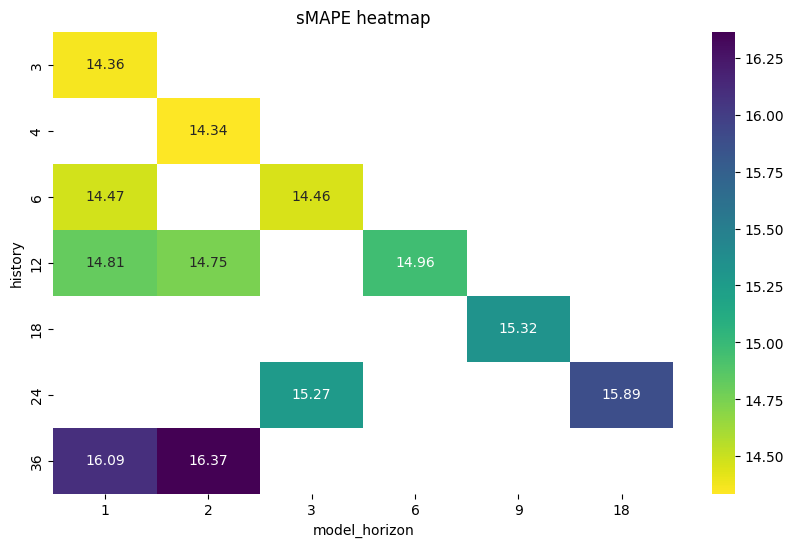

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_smape, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("sMAPE heatmap")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

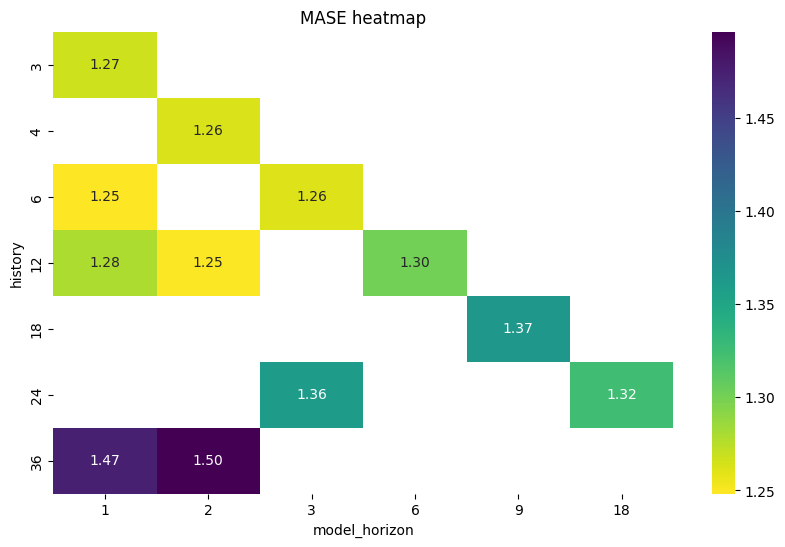

In [ ]:
pivot_mase = results_experiment.pivot(
    index="history",
    columns="model_horizon",
    values="MASE"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_mase, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("MASE heatmap")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

По результатам экспериментов видно, что увеличение истории приводит к ухудшению метрик, так как более далекая история может добавлять шум и усложнять обучение.

Точно такое же ухудшение метрик происходит при увеличении горизонта прогнозирования одной модели, поскольку задача становится сложнее: модель должна предсказывать значения на более дальние шаги вперед.

## Сезонные лаги с оптимальными model_horizon и history

Посмотрим на оптимальные model_horizon и history для обычных лагов и сезонных.

In [ ]:
lags_seasonal_12_config = {
    "use_id": True,
    "use_calendar": False,
    "selected_lags": [1, 2, 3, 6, 12],
    "use_fourier": False,
}
experiments_lags_seasonal = [
    {"model_horizon": 1, "history": 12},
    {"model_horizon": 2, "history": 12},
    {"model_horizon": 3, "history": 12},
    {"model_horizon": 1, "history": 18},
    {"model_horizon": 2, "history": 18},
    {"model_horizon": 3, "history": 18},
    {"model_horizon": 1, "history": 24},
    {"model_horizon": 2, "history": 24},
]
results_lags_seasonal = []
artifacts_lags_seasonal = {}

for cfg in experiments_lags_seasonal:
    model_horizon = cfg["model_horizon"]
    history = cfg["history"]

    print(f"Running: history={history}, model_horizon={model_horizon}")

    res = run_holdout_experiment(
        data=train,
        feature_config=lags_seasonal_12_config,
        model_horizon=model_horizon,
        history=history,
        horizon=18,
        freq="M",
        id_col="unique_id",
        timestamp_col="ds",
        value_col="y",
        seasonality=12,
    )

    results_lags_seasonal.append({
        "feature_set": "lags_seasonal_12",
        "model_horizon": model_horizon,
        "history": history,
        "sMAPE": res["sMAPE"],
        "MASE": res["MASE"],
    })

    artifacts_lags_seasonal[(model_horizon, history)] = res
results_lags_seasonal_df = pd.DataFrame(results_lags_seasonal)
results_lags_seasonal_df = results_lags_seasonal_df.sort_values(
    ["MASE", "sMAPE"]
).reset_index(drop=True)

results_lags_seasonal_df

Running: history=12, model_horizon=1
0:	learn: 3087.2222905	test: 3484.8897936	best: 3484.8897936 (0)	total: 18.8ms	remaining: 3.75s
100:	learn: 461.4457795	test: 685.4816058	best: 647.1486611 (53)	total: 1.1s	remaining: 1.08s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 647.1486611
bestIteration = 53

Shrink model to first 54 iterations.
0:	learn: 3087.3133820	test: 3598.6319826	best: 3598.6319826 (0)	total: 12.9ms	remaining: 2.57s
100:	learn: 519.6796141	test: 800.5212453	best: 778.0230504 (53)	total: 1.09s	remaining: 1.07s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 778.0230504
bestIteration = 53

Shrink model to first 54 iterations.
0:	learn: 3087.3585480	test: 3601.4893163	best: 3601.4893163 (0)	total: 13.8ms	remaining: 2.76s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 787.9375083
bestIteration = 46

Shrink model to first 47 iterations.
0:	learn: 3093.0789662	test: 3572.4325855	best: 3572.4325855 (0)	total: 12.2ms	re

,feature_set,model_horizon,history,sMAPE,MASE
0,lags_seasonal_12,2,24,14.179390,1.220086
1,lags_seasonal_12,1,18,14.120569,1.231356
2,lags_seasonal_12,1,24,14.078579,1.238028
3,lags_seasonal_12,3,18,14.449169,1.243540
4,lags_seasonal_12,2,12,14.417785,1.250221
5,lags_seasonal_12,1,12,14.276945,1.251605
6,lags_seasonal_12,2,18,14.171952,1.253692
7,lags_seasonal_12,3,12,14.535500,1.278305


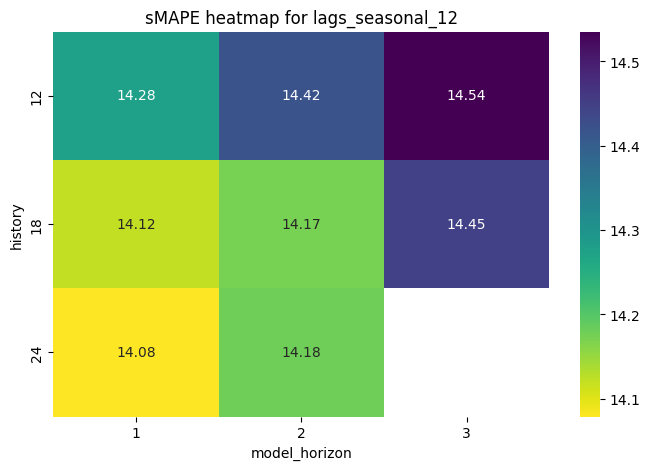

In [ ]:
pivot_smape_seasonal = results_lags_seasonal_df.pivot(
    index="history",
    columns="model_horizon",
    values="sMAPE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_smape_seasonal, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("sMAPE heatmap for lags_seasonal_12")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

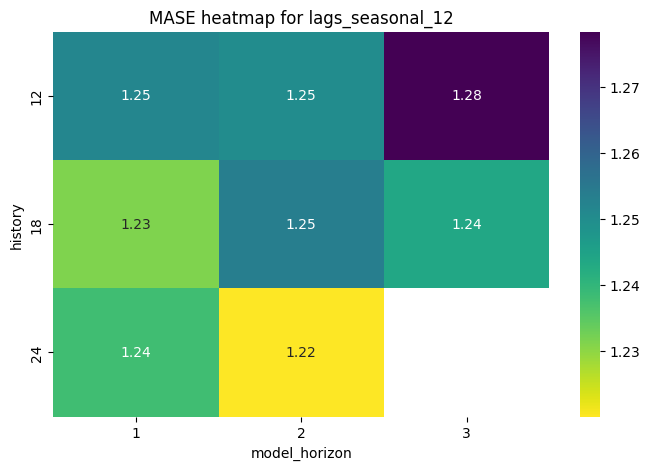

In [ ]:
pivot_mase_seasonal = results_lags_seasonal_df.pivot(
    index="history",
    columns="model_horizon",
    values="MASE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_mase_seasonal, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("MASE heatmap for lags_seasonal_12")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

Эксперименты показали, что учет сезонности позволяет снизить ошибку по сравнению с использованием только лаговых признаков: значение MASE уменьшилось до 1.22.

Наилучшие результаты были достигнуты при history = 24 и model_horizon = 2, что подтверждает важность учета сезонной структуры временного ряда и использования полного сезонного окна. При этом, как и ранее, увеличение горизонта модели приводит к ухудшению качества прогноза, в отличие от увеличения истории.

Несмотря на улучшение, модели не удалось превзойти наивный прогноз на трейне(MASE < 1).


## Сезонные лаги и календарные признаки с оптимальными model_horizon и history

In [ ]:
lags_seasonal_calendar_12_config = {
    "use_id": True,
    "use_calendar": True,
    "selected_lags": [1, 2, 3, 6, 12],
    "use_fourier": False,
}

experiments_lags_seasonal_calendar = [
    {"model_horizon": 1, "history": 12},
    {"model_horizon": 2, "history": 12},
    {"model_horizon": 3, "history": 12},
    {"model_horizon": 1, "history": 18},
    {"model_horizon": 2, "history": 18},
    {"model_horizon": 3, "history": 18},
    {"model_horizon": 1, "history": 24},
    {"model_horizon": 2, "history": 24},
]

results_lags_seasonal_calendar = []
artifacts_lags_seasonal_calendar = {}

for cfg in experiments_lags_seasonal_calendar:
    model_horizon = cfg["model_horizon"]
    history = cfg["history"]

    print(f"Running: history={history}, model_horizon={model_horizon}")

    res = run_holdout_experiment(
        data=train,
        feature_config=lags_seasonal_calendar_12_config,
        model_horizon=model_horizon,
        history=history,
        horizon=18,
        freq="M",
        id_col="unique_id",
        timestamp_col="ds",
        value_col="y",
        seasonality=12,
    )

    results_lags_seasonal_calendar.append({
        "feature_set": "lags_seasonal_calendar_12",
        "model_horizon": model_horizon,
        "history": history,
        "sMAPE": res["sMAPE"],
        "MASE": res["MASE"],
    })

    artifacts_lags_seasonal_calendar[(model_horizon, history)] = res

results_lags_seasonal_calendar_df = pd.DataFrame(results_lags_seasonal_calendar)
results_lags_seasonal_calendar_df = results_lags_seasonal_calendar_df.sort_values(
    ["MASE", "sMAPE"]
).reset_index(drop=True)

results_lags_seasonal_calendar_df

Running: history=12, model_horizon=1
0:	learn: 3088.7664319	test: 3493.3209665	best: 3493.3209665 (0)	total: 59.5ms	remaining: 11.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 659.7662607
bestIteration = 38

Shrink model to first 39 iterations.
0:	learn: 3087.7278650	test: 3593.3846082	best: 3593.3846082 (0)	total: 25.2ms	remaining: 5.02s
100:	learn: 527.8013874	test: 744.0552947	best: 743.5615462 (98)	total: 2.32s	remaining: 2.28s
199:	learn: 465.3664562	test: 737.7038248	best: 735.9610818 (183)	total: 4.49s	remaining: 0us

bestTest = 735.9610818
bestIteration = 183

Shrink model to first 184 iterations.
0:	learn: 3089.0762063	test: 3605.1236139	best: 3605.1236139 (0)	total: 23.7ms	remaining: 4.72s
100:	learn: 570.0641309	test: 779.3911160	best: 741.6703570 (57)	total: 2.18s	remaining: 2.14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 741.670357
bestIteration = 57

Shrink model to first 58 iterations.
0:	learn: 3090.1482138	test: 3537.41502

,feature_set,model_horizon,history,sMAPE,MASE
0,lags_seasonal_calendar_12,1,24,14.249571,1.267632
1,lags_seasonal_calendar_12,2,12,14.480724,1.284715
2,lags_seasonal_calendar_12,1,18,14.443596,1.300199
3,lags_seasonal_calendar_12,2,24,14.598348,1.337024
4,lags_seasonal_calendar_12,1,12,14.800428,1.353607
5,lags_seasonal_calendar_12,3,12,14.704377,1.361804
6,lags_seasonal_calendar_12,2,18,14.803980,1.387850
7,lags_seasonal_calendar_12,3,18,14.944381,1.413921


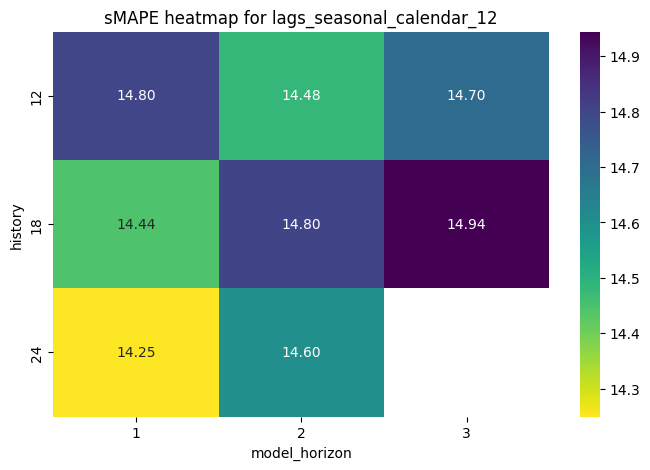

In [ ]:
pivot_smape_seasonal_calendar = results_lags_seasonal_calendar_df.pivot(
    index="history",
    columns="model_horizon",
    values="sMAPE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_smape_seasonal_calendar, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("sMAPE heatmap for lags_seasonal_calendar_12")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

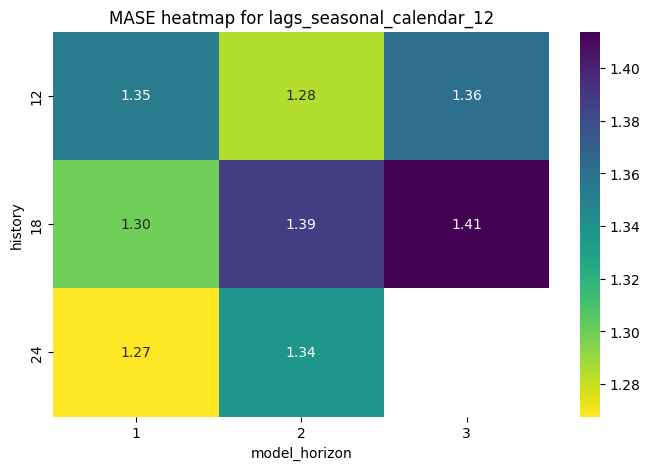

In [ ]:
pivot_mase_seasonal_calendar = results_lags_seasonal_calendar_df.pivot(
    index="history",
    columns="model_horizon",
    values="MASE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_mase_seasonal_calendar, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("MASE heatmap for lags_seasonal_calendar_12")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

Дополнительно была исследована комбинация лаговых, сезонных и календарных признаков. Результаты показали, что добавление календарных признаков не приводит к улучшению качества модели, а в ряде конфигураций даже ухудшает значения метрик.

Это объясняется тем, что информация о сезонности уже содержится в лаговых признаках (в частности, в сезонных лагах), а календарные признаки оказываются избыточными и увеличивают сложность модели, что может приводить к переобучению.

Таким образом, наилучшие результаты были получены при использовании только лаговых и сезонных признаков без добавления календарных факторов.


## Визуализация прогнозов лучшей модели по MASE

In [14]:
lags_seasonal_12_config = {
    "use_id": True,
    "use_calendar": False,
    "selected_lags": [1, 2, 3, 6, 12],
    "use_fourier": False,
}

In [15]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_best_MASE = run_holdout_experiment(
    data=train,
    feature_config=lags_seasonal_12_config,
    model_horizon=2,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_best_MASE["sMAPE"])
print("MASE:", result_best_MASE["MASE"])

0:	learn: 4376.0045198	test: 5039.9486673	best: 5039.9486673 (0)	total: 130ms	remaining: 25.8s
100:	learn: 689.4511284	test: 1023.8899522	best: 1017.2386075 (55)	total: 4.38s	remaining: 4.29s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1017.238608
bestIteration = 55

Shrink model to first 56 iterations.
0:	learn: 4384.8199835	test: 5093.9347569	best: 5093.9347569 (0)	total: 26.6ms	remaining: 5.28s
100:	learn: 846.9916902	test: 1201.9705619	best: 1102.4658485 (52)	total: 2.63s	remaining: 2.58s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1102.465848
bestIteration = 52

Shrink model to first 53 iterations.
0:	learn: 4395.6606415	test: 5440.2360333	best: 5440.2360333 (0)	total: 27.8ms	remaining: 5.53s
100:	learn: 952.8490221	test: 2100.9317948	best: 2097.2385179 (79)	total: 2.55s	remaining: 2.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2095.193537
bestIteration = 116

Shrink model to first 117 iterations.
0:	learn: 4418.9

In [22]:
plot_forecast(
    train_df=result_best_MASE["train_df"],
    eval_df=result_best_MASE["merged_predictions"],
    series_id="M10756",
    models=["predicted_value"],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Best model forecast"
)

In [26]:
plot_forecast(
    train_df=result_best_MASE["train_df"],
    eval_df=result_best_MASE["merged_predictions"],
    series_id="M4556",
    models=["predicted_value"],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Best model forecast"
)

In [28]:
plot_forecast(
    train_df=result_best_MASE["train_df"],
    eval_df=result_best_MASE["merged_predictions"],
    series_id="M41162",
    models=["predicted_value"],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Best model forecast"
)

На визуализации прогнозов для различных рядов видно, что качество модели существенно варьируется в зависимости от структуры ряда.

Для части рядов модель хорошо улавливает общий уровень и динамику, обеспечивая близкие к реальным значениям прогнозы. Однако в более сложных случаях наблюдается сглаживание предсказаний: модель не воспроизводит локальные пики и спады. Классические модели справляются с сезонностью гораздо лучше.

Особенно заметно ухудшение качества на рядах с резкими выбросами, которые модель не способна предсказать на основе лаговых признаков.

# Общий вывод

В ходе работы были исследованы различные подходы к прогнозированию временных рядов, включая базовые модели (Naive, Seasonal Naive, AutoETS, AutoTheta) и ML-подход с использованием лаговых, сезонных, календарных и Фурье-признаков. В качестве метрик качества были выбраны sMAPE и MASE, позволяющие оценить как относительную ошибку прогноза, так и его качество по сравнению с наивной моделью.

Базовые модели показали сильные результаты, особенно AutoTheta и AutoETS, которые обеспечили наилучшие значения метрики MASE < 1. Это указывает на то, что классические методы хорошо захватывают тренд и сезонность во временных рядах.

В рамках Direct MIMO подхода было установлено, что использование только лаговых признаков не позволяет превзойти наивный прогноз. Добавление сезонных лагов приводит к улучшению качества модели и снижению значения MASE, что подтверждает важность учета сезонной структуры данных, наличие которой подтвердилось графиками ACF. При этом наилучшие результаты были достигнуты при использовании history = 24 и небольшого горизонта модели (model_horizon = 1 или 2).

Дополнительное включение календарных признаков не дало улучшения и в ряде случаев ухудшило качество прогноза, что связано с избыточностью информации и возможным переобучением модели.

Несмотря на проведенные улучшения, ни одна из ML-моделей не смогла превзойти лучшие базовые подходы по метрике MASE. Это свидетельствует о высокой сложности задачи и эффективности классических методов для рассматриваемых рядов. Хотя, в то же время, удалось снизить метрику sMAPE с 15 до 14.08.

Таким образом, модель может лучше улавливать общую динамику ряда (что отражается в снижении sMAPE), но при этом проигрывать наивному прогнозу в терминах абсолютной ошибки. Это особенно характерно для рядов, где наивный прогноз уже является сильным бейзлайном.
